# 실습 1. PCA와 LDA 차원축소

Wine 데이터셋을 사용해 PCA와 LDA 차원축소 흐름을 복습함.

## 데이터셋
- 데이터: scikit-learn `load_wine`
- 샘플 수: 178개
- feature 수: 13개
- target: 와인 품종 3개(`class_0`, `class_1`, `class_2`)

이번 실습에서는 Iris가 아닌 Wine 데이터를 사용함. 교안에서 배운 `train_test_split`, `StandardScaler`, `PCA`, `LinearDiscriminantAnalysis`, `RandomForestClassifier`만 사용함.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

wine = load_wine(as_frame=True)
wine_X = wine.data.copy()
wine_y = wine.target.copy()
wine_target_names = dict(enumerate(wine.target_names))

wine_df = wine_X.copy()
wine_df['target'] = wine_y
wine_df['target_name'] = wine_df['target'].map(wine_target_names)

display(wine_df.head())
print('feature shape:', wine_X.shape)
print('target shape:', wine_y.shape)
print('target names:', wine.target_names)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


feature shape: (178, 13)
target shape: (178,)
target names: ['class_0' 'class_1' 'class_2']


## 문제 1. 학습/평가 데이터 분리와 스케일링

`wine_X`, `wine_y`를 학습/평가 데이터로 나누고 `StandardScaler`로 feature 스케일을 맞추세요.

요구사항:
- `test_size=0.2`, `random_state=42`, `stratify=wine_y` 사용
- 변수명은 `wine_X_train`, `wine_X_test`, `wine_y_train`, `wine_y_test` 사용
- 스케일링 결과는 `wine_X_train_scaled`, `wine_X_test_scaled`에 저장

### 실행 결과
```text
wine_X_train: (142, 13)
wine_X_test: (36, 13)
wine_y_train: (142,)
wine_y_test: (36,)
scaled train mean: 0.0
scaled train std: 1.0
```


In [23]:
scaler = StandardScaler()
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X,
    wine_y,
    test_size=0.2,
    random_state=42,
    stratify=wine_y
)

wine_X_train_scaled = scaler.fit_transform(wine_X_train)
wine_X_test_scaled = scaler.transform(wine_X_test)
print('wine_X_train:', wine_X_train_scaled.shape)
print('wine_X_test:', wine_X_test_scaled.shape)
print('wine_y_train:', wine_y_train.shape)
print('wine_y_test:', wine_y_test.shape)
print('scaled train mean:', round(wine_X_train_scaled.mean(), 1) + 0.0)
print('scaled train std:', round(wine_X_train_scaled.std(), 1))

wine_X_train: (142, 13)
wine_X_test: (36, 13)
wine_y_train: (142,)
wine_y_test: (36,)
scaled train mean: 0.0
scaled train std: 1.0


## 문제 2. PCA 2차원 변환과 설명 분산 비율 확인

`PCA(n_components=2)`로 train/test 데이터를 2차원으로 변환하고, `explained_variance_ratio_`와 누적 설명 분산 비율을 표로 확인하세요.

요구사항:
- 변수명은 `wine_pca`, `wine_train_pca_2d`, `wine_test_pca_2d` 사용
- 결과표 변수명은 `wine_pca_explained_df` 사용

### 실행 결과
```text
  component  explained_variance_ratio  cumulative_explained_ratio
0       PC1                    0.3579                      0.3579
1       PC2                    0.1927                      0.5506
```


In [18]:
# 원본 feature(13개) 정보를 주성분 2개로 압축
wine_pca = PCA(n_components=2)

# fit_transform(): train 데이터에서 PCA 축을 학습 -> 새 축(2개)로 변환
wine_train_pca_2d = wine_pca.fit_transform(wine_X_train_scaled)

# transform(): test 데이터에서 학습으로 얻은 2개의 축에 맞게 test 데이터 변환
wine_test_pca_2d = wine_pca.transform(wine_X_test_scaled)

# explained_variance_ratio_ : 각 주성분이 설명하는 분산 비율
# cumsum() : 앞 주성분부터 누적해서 원본 정보가 얼마나 남았는지를 계산
wine_pca_explained_df = pd.DataFrame({
    'component': ['PC1', 'PC2'],
    'explained_variance_ratio': wine_pca.explained_variance_ratio_,
    'cumulative_explained_ratio': np.cumsum(wine_pca.explained_variance_ratio_),
})

display(wine_pca_explained_df.round(4))

,component,explained_variance_ratio,cumulative_explained_ratio
0,PC1,0.3579,0.3579
1,PC2,0.1927,0.5506


## 문제 3. PCA 결과 시각화

PCA로 만든 `PC1`, `PC2` 좌표를 DataFrame으로 정리하고, 실제 와인 품종별 색이 다른 산점도를 그리세요.

요구사항:
- train/test를 구분하는 `split` 컬럼 생성
- `sns.scatterplot()` 사용
- x축 `PC1`, y축 `PC2`, 색상 `target_name`, 모양 `split`

### 실행 결과
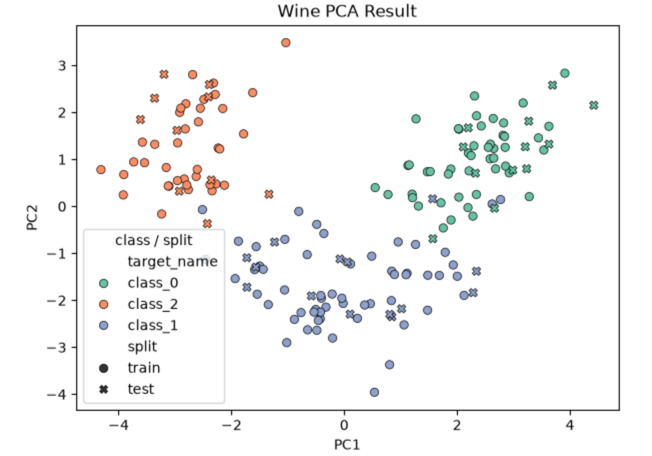


,PC1,PC2,target,target_name,split
0,1.472343,0.734251,0,class_0,train
1,2.649709,1.230211,0,class_0,train
2,1.888788,0.792472,0,class_0,train
3,2.211159,0.753458,0,class_0,train
4,-2.817571,1.645688,2,class_2,train


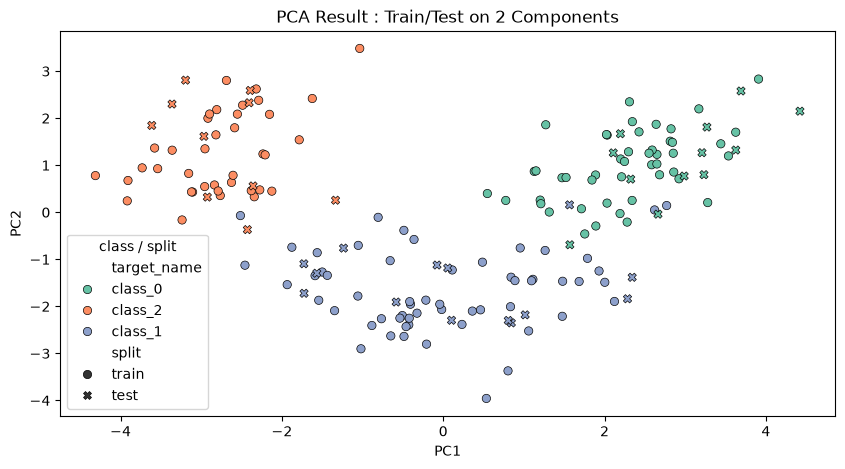

In [25]:
# 시각화 및 결과 확인용 DF 생성
wine_pca_train_df = pd.DataFrame(wine_train_pca_2d, columns=['PC1', 'PC2'])
wine_pca_train_df['target'] = wine_y_train.to_numpy()
wine_pca_train_df['target_name'] = wine_pca_train_df['target'].map(wine_target_names)
wine_pca_train_df['split'] = 'train'

wine_pca_test_df = pd.DataFrame(wine_test_pca_2d, columns=['PC1', 'PC2'])
wine_pca_test_df['target'] = wine_y_test.to_numpy()
wine_pca_test_df['target_name'] = wine_pca_test_df['target'].map(wine_target_names)
wine_pca_test_df['split'] = 'test'

wine_pca_result_df = pd.concat([wine_pca_train_df, wine_pca_test_df], ignore_index=True)

display(wine_pca_result_df.head())

plt.figure(figsize=(10, 5))

sns.scatterplot(
    wine_pca_result_df,
    x='PC1',
    y='PC2',
    hue='target_name',
    style='split',
    palette='Set2',
    edgecolor='black',
)

plt.title('PCA Result : Train/Test on 2 Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='class / split')
plt.show()

## 문제 4. LDA 2차원 변환과 설명 비율 확인

`LinearDiscriminantAnalysis(n_components=2)`로 train/test 데이터를 2차원으로 변환하고 설명 비율을 확인하세요.

요구사항:
- 변수명은 `wine_lda`, `wine_train_lda_2d`, `wine_test_lda_2d` 사용
- LDA는 `fit_transform()`할 때 `wine_y_train`이 필요함

### 실행 결과
```text
  component  explained_variance_ratio  cumulative_explained_ratio
0       LD1                    0.6935                      0.6935
1       LD2                    0.3065                      1.0000
```


In [20]:
# class 정보를 이용해 2차원의 판별 축을 만듦
wine_lda = LinearDiscriminantAnalysis(n_components=2)

# LDA는 학습 시 target(y)가 포함 되어야 한다
wine_train_lda_2d = wine_lda.fit_transform(wine_X_train_scaled, wine_y_train)
wine_test_lda_2d = wine_lda.transform(wine_X_test_scaled)

wine_lda_explained_df = pd.DataFrame({
    'component': ['LD1', 'LD2'],
    'explained_variance_ratio': wine_lda.explained_variance_ratio_,
    'cumulative_explained_ratio': np.cumsum(wine_lda.explained_variance_ratio_),
})

display(wine_lda_explained_df.round(4))

,component,explained_variance_ratio,cumulative_explained_ratio
0,LD1,0.6935,0.6935
1,LD2,0.3065,1.0000


## 문제 5. 원본 feature, PCA feature, LDA feature 모델 성능 비교

같은 `RandomForestClassifier`를 사용해 원본 feature, PCA 2차원 feature, LDA 2차원 feature의 성능을 비교하세요.

요구사항:
- 결과를 `wine_comparison_df`에 저장
- `input_data`, `feature_count`, `train_accuracy`, `test_accuracy` 컬럼 포함

### 실행 결과
```text
             input_data  feature_count  train_accuracy  test_accuracy
0  original_13_features             13             1.0         1.0000
1      pca_2_components              2             1.0         0.8889
2      lda_2_components              2             1.0         0.9722
```


In [21]:
# 원본 feature 모델: 13개 feature를 그대로 사용함.
raw_clf = RandomForestClassifier(random_state=42)
raw_clf.fit(wine_X_train, wine_y_train)

# PCA feature 모델: train에서 학습한 PCA 2차원 feature를 사용함.
pca_clf = RandomForestClassifier(random_state=42)
pca_clf.fit(wine_train_pca_2d, wine_y_train)

# LDA feature 모델: train에서 학습한 LDA 2차원 feature를 사용함.
lda_clf = RandomForestClassifier(random_state=42)
lda_clf.fit(wine_train_lda_2d, wine_y_train)

wine_comparison_df = pd.DataFrame([
    {
        'input_data': 'original_13_features',
        'feature_count': wine_X_train.shape[1],
        'train_accuracy': raw_clf.score(wine_X_train, wine_y_train),
        'test_accuracy': raw_clf.score(wine_X_test, wine_y_test),
    },
    {
        'input_data': 'pca_2_components',
        'feature_count': wine_train_pca_2d.shape[1],
        'train_accuracy': pca_clf.score(wine_train_pca_2d, wine_y_train),
        'test_accuracy': pca_clf.score(wine_test_pca_2d, wine_y_test),
    },
    {
        'input_data': 'lda_2_components',
        'feature_count': wine_train_lda_2d.shape[1],
        'train_accuracy': lda_clf.score(wine_train_lda_2d, wine_y_train),
        'test_accuracy': lda_clf.score(wine_test_lda_2d, wine_y_test),
    }
])

display(wine_comparison_df)

,input_data,feature_count,train_accuracy,test_accuracy
0,original_13_features,13,1.0,1.000000
1,pca_2_components,2,1.0,0.888889
2,lda_2_components,2,1.0,0.972222
